In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('train.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,52,Private,210736,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,3103,0,55,United-States,>50K
1,62,Private,209844,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,30,United-States,<=50K
2,25,Private,410240,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0,0,40,United-States,<=50K
3,28,Private,90547,HS-grad,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,23,United-States,<=50K
4,28,Private,132326,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,40,United-States,<=50K


In [12]:
df = pd.get_dummies(df, df.select_dtypes(include=['object']).columns)
df = df.drop('income_<=50K', axis=1)
df.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,52,210736,10,3103,0,55,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
1,62,209844,10,0,0,30,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,25,410240,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,28,90547,9,0,0,23,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,28,132326,9,0,0,40,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [13]:
df = df.sample(frac=1, random_state=816124)

X = df.drop('income_>50K', axis=1)
y = df['income_>50K']

split_idx = int(0.8 * len(X))
trainX, validX = X[:split_idx], X[split_idx:]
trainY, validY = y[:split_idx], y[split_idx:]

mean = trainX.mean(axis=0)
std = trainX.std(axis=0)
trainX = (trainX - mean) / std
validX = (validX - mean) / std

print("Shape of trainX:", trainX.shape)
print("Shape of validX:", validX.shape)

Shape of trainX: (31258, 108)
Shape of validX: (7815, 108)


In [14]:
class LogisticRegression:
    
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y, batch_size=64, lr=0.001, alpha=0, epoch=100):
        # Initialize weights and bias
        X, y = np.array(X), np.array(y)
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Iterate through epochs
        for i in range(epoch):

            # Split the data into batches
            n_batches = int(np.ceil(len(X) / batch_size))
            for b in range(n_batches):
                start = b * batch_size
                end = min(start + batch_size, len(X))
                
                X_batch, y_batch = X[start:end], y[start:end]

                # Forward propagation
                y_pred = self.predict(X_batch, return_prob=True)

                # Backward propagation
                dZ = y_pred - y_batch
                dW = np.dot(X_batch.T, dZ) / batch_size + alpha * (self.weights**2)
                print(self.weights**2)
                db = np.sum(dZ, axis=0, keepdims=True) / batch_size

                # Update weights and bias
                self.weights -= lr * dW
                self.bias -= lr * db
            
    def predict(self, X, return_prob=False):
        z = np.dot(X, self.weights) + self.bias
        
        if return_prob:
            probs = self.sigmoid(z)
            return probs
        else:
            preds = np.where(self.sigmoid(z) > 0.5, 1, 0)
            return preds

    def evaluate(self, X, y):
        y_pred = self.predict(X)
        return self.accuracy_score(y, y_pred)
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def accuracy_score(self, y, y_pred):
        return np.mean(y == y_pred)

In [15]:
lr = 0.01
batch_size = 32
epoch = 100

model = LogisticRegression()
model.fit(trainX, trainY, lr=lr, batch_size=batch_size, epoch=epoch)

print('Training acc: ', model.evaluate(trainX, trainY))
print('Testing acc: ', model.evaluate(validX, validY))

Training acc:  0.8529336489858597
Testing acc:  0.8446577095329495


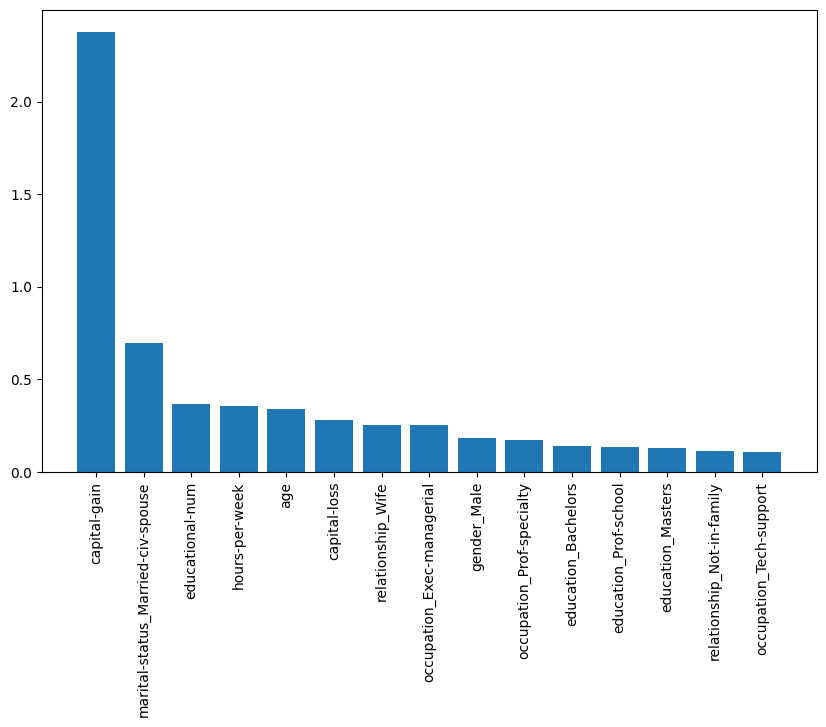

In [16]:
weights = np.abs(model.weights)
weights = model.weights

columns = trainX.columns.tolist()
df = pd.DataFrame(data=weights, index=columns, columns=['weights'])
df = df.sort_values('weights', ascending=False)

visualize_count = 15
plt.figure(figsize=(10, 6))
plt.bar(x=df.index[:visualize_count], height=df['weights'][:visualize_count])
plt.xticks(rotation=90)
plt.show()

/var/folders/z6/bsrcqf1572x8kz33hppk66f80000gn/T/ipykernel_99563/3329546285.py:52: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/var/folders/z6/bsrcqf1572x8kz33hppk66f80000gn/T/ipykernel_99563/3329546285.py:30: RuntimeWarning: overflow encountered in square
  dW = np.dot(X_batch.T, dZ) / batch_size + alpha * (self.weights**2)


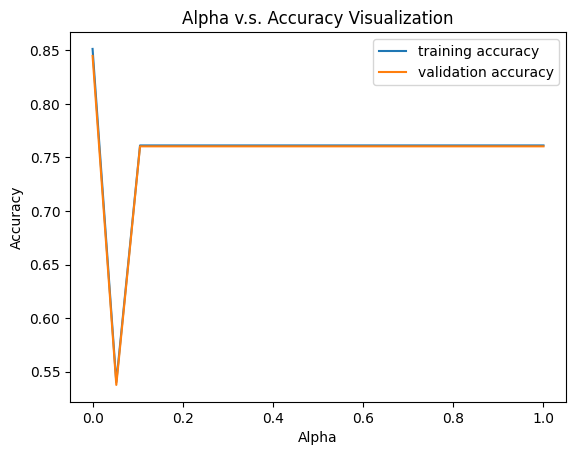

In [17]:
lr = 0.01
batch_size = 32
epoch = 10

alphas = np.linspace(0, 1, 20)
train_accuracy = []
valid_accuracy = []

for alpha in alphas:
    model = LogisticRegression()
    model.fit(trainX, trainY, lr=lr, batch_size=batch_size, alpha=alpha, epoch=epoch)
    train_accuracy.append(model.evaluate(trainX, trainY))
    valid_accuracy.append(model.evaluate(validX, validY))

plt.figure()
plt.plot(alphas, train_accuracy, label='training accuracy')
plt.plot(alphas, valid_accuracy, label='validation accuracy')
plt.title('Alpha v.s. Accuracy Visualization')
plt.ylabel('Accuracy')
plt.xlabel('Alpha')
plt.legend()
plt.show()

In [18]:
testX = pd.read_csv('test_X.csv')
testX = pd.get_dummies(testX, testX.select_dtypes(include=['object']).columns)

missing_cols = set(trainX.columns) - set(testX.columns)
for col in missing_cols:
    testX[col] = 0
testX = testX[trainX.columns]

testX = (testX - mean) / std
predY = model.predict(testX)

df = pd.DataFrame({
    'id': np.arange(len(predY)),
    'income': predY
})
df.to_csv('submission.csv', index=False)